In [2]:
import os, re, joblib, numpy as np, pandas as pd
from tqdm import tqdm
from sklearn.utils import shuffle, resample
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz
from sentence_transformers import SentenceTransformer, util
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
import platform, warnings
from xgboost import XGBClassifier
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os, re, joblib, numpy as np, pandas as pd
from tqdm import tqdm
from sklearn.utils import shuffle, resample
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz
from sentence_transformers import SentenceTransformer, util
import torch
from pathlib import Path
from catboost import CatBoostClassifier

In [3]:
import pandas as pd
df = pd.read_csv("./train_data.csv")
df.head()

,claim,evidence,verifiable,label
0,The number of new cases of shingles per year e...,The number of new cases per year ranges from 1...,VERIFIABLE,SUPPORTS
1,Gabrielle Union was in a movie.,She co-starred in film The Birth of a Nation -...,VERIFIABLE,SUPPORTS
2,Eleveneleven was founded by a chef.,eleveneleven is a record label founded in 2010...,VERIFIABLE,REFUTES
3,Cosmos: A Spacetime Odyssey secured studio sup...,MacFarlane served as executive producer of Cos...,NOT VERIFIABLE,NOT ENOUGH INFO
4,The World According to Paris starred Hilton's ...,"It was filmed from November 2010 , with Hilton...",NOT VERIFIABLE,NOT ENOUGH INFO


In [4]:
#-----------Device Config-----------
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

SAMPLE_SIZE = 250000
CACHE_DIR = Path("./cache")
CACHE_DIR.mkdir(exist_ok=True)


#-----------Sampling-----------
required_cols = {"claim", "evidence", "verifiable", "label"}
assert required_cols.issubset(df.columns)

sample_df = shuffle(df, random_state=42)
if len(sample_df) > SAMPLE_SIZE:
    sample_df = sample_df.sample(n=SAMPLE_SIZE, random_state=42)
sample_df = sample_df.reset_index(drop=True)

print(f"Size of df: {len(sample_df)} rows")


#---------Cleaning--------
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"<.*?>", " ", s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()

sample_df["claim_clean"] = sample_df["claim"].apply(clean_text)
sample_df["evidence_clean"] = sample_df["evidence"].apply(clean_text)

#-----Label Encoding-----------
label_enc = LabelEncoder()
sample_df["label_enc"] = label_enc.fit_transform(sample_df["label"])
joblib.dump(label_enc, CACHE_DIR / "label_encoder.joblib")

#------Verifiable or not-------
def map_verifiable(x):
    s = str(x).lower()
    if "non" in s or "not" in s:
        return 0
    return 1 if "verif" in s else 0
sample_df["verifiable_flag"] = sample_df["verifiable"].apply(map_verifiable)

#--------Up sampling------
print("\nLabel distribution (before balancing):")
print(sample_df["label"].value_counts())

majority = sample_df[sample_df["label"] != "REFUTES"]
minority = sample_df[sample_df["label"] == "REFUTES"]

if not minority.empty:
    minority_up = resample(minority, replace=True,
                           n_samples=max(len(majority)//2, len(minority)),
                           random_state=42)
    sample_df = pd.concat([majority, minority_up]).reset_index(drop=True)

print("\nLabel distribution (after upsampling):")
print(sample_df["label"].value_counts())

#----------Embeddings-------------------
claim_cache = CACHE_DIR / "claim_emb.npy"
evidence_cache = CACHE_DIR / "evidence_emb.npy"

print("\nLoading or generating embeddings...")
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

if claim_cache.exists() and evidence_cache.exists() and np.load(claim_cache).shape[0] == len(sample_df):
    claim_emb = np.load(claim_cache)
    evidence_emb = np.load(evidence_cache)
else:
    claim_emb = model.encode(sample_df["claim_clean"].tolist(), convert_to_numpy=True, show_progress_bar=True)
    evidence_emb = model.encode(sample_df["evidence_clean"].tolist(), convert_to_numpy=True, show_progress_bar=True)
    np.save(claim_cache, claim_emb)
    np.save(evidence_cache, evidence_emb)

print("Embeddings shapes:", claim_emb.shape, evidence_emb.shape)

#-----------TF-IDF-----------
tfidf_cache = CACHE_DIR / "tfidf_vectorizer.joblib"
tfidf_feat_cache = CACHE_DIR / "tfidf_features.npz"

def compute_tfidf(df, cache_vec, cache_feat):
    df["combo"] = df["claim_clean"] + " " + df["evidence_clean"]
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,3), stop_words="english")
    tfidf_features = tfidf.fit_transform(df["combo"])
    joblib.dump(tfidf, cache_vec)
    save_npz(cache_feat, tfidf_features)
    return tfidf, tfidf_features

if tfidf_cache.exists() and tfidf_feat_cache.exists():
    tfidf = joblib.load(tfidf_cache)
    tfidf_features = load_npz(tfidf_feat_cache)
else:
    tfidf, tfidf_features = compute_tfidf(sample_df, tfidf_cache, tfidf_feat_cache)

print("TF-IDF shape:", tfidf_features.shape)


#----------Num Flag-----------
def extract_nums(s):
    return re.findall(r"\d+", s) if isinstance(s, str) else []
def num_contradiction(c, e):
    cnums, enums = set(extract_nums(c)), set(extract_nums(e))
    if not cnums or not enums:
        return -1    
    return 1 if cnums.isdisjoint(enums) else 0

#----------Semantic conflict---------
def semantic_conflict(c, e, model=model, threshold=0.35):
    if not c or not e:
        return 0
    emb_c = model.encode(c, convert_to_tensor=True, device=device)
    emb_e = model.encode(e, convert_to_tensor=True, device=device)
    sim = util.cos_sim(emb_c, emb_e).item()
    if sim < -0.15:
        return 2   
    if sim < threshold:
        return 1   
    return 0

#-----Matching Negations------------
def negation_mismatch(c, e):
    neg_words = {"not", "no", "never", "none", "doesn't", "isnt", "isn't"}
    c_neg = any(w in c.split() for w in neg_words)
    e_neg = any(w in e.split() for w in neg_words)
    return int(c_neg != e_neg)

def direct_negation_conflict(c, e):
    c_words = c.split()
    e_words = e.split()
    for i in range(len(e_words)-1):
        if e_words[i] == "not" and e_words[i+1] in c_words:
            return 1
    return 0

#-------Loading handcratfted features--------------------
num_sem_cache = CACHE_DIR / "num_sem_features.npy"

if num_sem_cache.exists():
    num_sem_features = np.load(num_sem_cache)
    sample_df["num_contradiction"] = num_sem_features[:,0]
    sample_df["semantic_conflict"] = num_sem_features[:,1]
    sample_df["negation_flag"]       = num_sem_features[:, 2]
    sample_df["directnegation_flag"] = num_sem_features[:, 3]
else:
    tqdm.pandas()
    sample_df["num_contradiction"] = sample_df.progress_apply(lambda r: num_contradiction(r["claim"], r["evidence"]), axis=1)
    sample_df["semantic_conflict"] = sample_df.progress_apply(lambda r: semantic_conflict(r["claim_clean"], r["evidence_clean"]), axis=1)
    sample_df["negation_flag"] = sample_df.progress_apply(lambda r: negation_mismatch(r["claim_clean"], r["evidence_clean"]),axis=1)
    sample_df["directnegation_flag"] = sample_df.progress_apply(lambda r: direct_negation_conflict(r["claim_clean"], r["evidence_clean"]),axis=1)
    num_sem_features = sample_df[["num_contradiction","semantic_conflict","negation_flag","directnegation_flag"]].to_numpy()
    np.save(num_sem_cache, num_sem_features)

#-----Cosine sim score------
cosine_sim = np.array([
    cosine_similarity(claim_emb[i].reshape(1,-1), evidence_emb[i].reshape(1,-1))[0,0]
    for i in range(len(sample_df))
]).reshape(-1,1)

#-----Adding features-------
handcrafted = sample_df[[
    "verifiable_flag",
    "num_contradiction",
    "semantic_conflict",
    "negation_flag",
    "directnegation_flag"
]].to_numpy()

#-------Final Combination---------
emb_features = np.hstack([
    np.abs(claim_emb - evidence_emb),
    claim_emb * evidence_emb,
    claim_emb, evidence_emb,
    cosine_sim,
    handcrafted
])

#----------Converting into sparse matrix for coord-------
emb_sparse = csr_matrix(emb_features)
X_combined = hstack([emb_sparse, tfidf_features], format="csr")

#--------------Preparing labels and saving matrix shape--------------
y = sample_df["label_enc"].values
joblib.dump(X_combined.shape, CACHE_DIR / "x_combined_shape.joblib")

print(f"\nFinal feature matrix for sample_df: {X_combined.shape}")
print("Preprocessing completed successfully.")


Using device: mps
Size of df: 250000 rows

Label distribution (before balancing):
label
SUPPORTS           128477
NOT ENOUGH INFO     69927
REFUTES             51596
Name: count, dtype: int64

Label distribution (after upsampling):
label
SUPPORTS           128477
REFUTES             99202
NOT ENOUGH INFO     69927
Name: count, dtype: int64

Loading or generating embeddings...
Embeddings shapes: (297606, 384) (297606, 384)
TF-IDF shape: (297606, 5000)

Final feature matrix for sample_df: (297606, 6542)
Preprocessing completed successfully.


Logistic Regression Results:

                 precision    recall  f1-score   support

NOT ENOUGH INFO       1.00      1.00      1.00     13985
        REFUTES       0.79      0.78      0.78     19841
       SUPPORTS       0.83      0.84      0.83     25696

       accuracy                           0.86     59522
      macro avg       0.87      0.87      0.87     59522
   weighted avg       0.86      0.86      0.86     59522



<Figure size 500x500 with 0 Axes>

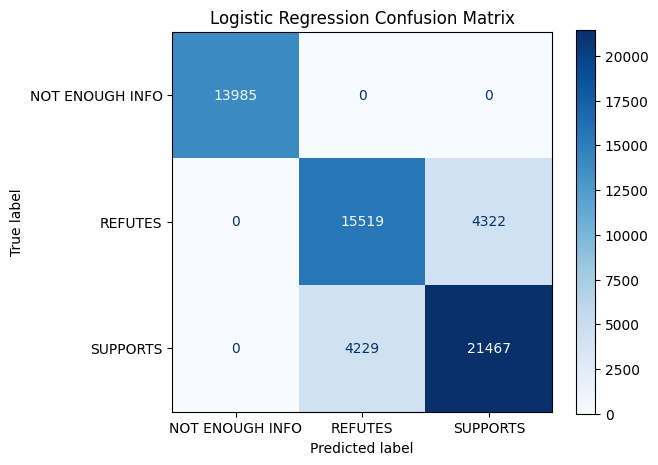


Model Performance
Training Accuracy:0.8678
Test Accuracy:0.8563
Model shows balanced generalization
Logistic Regression model saved as 'lr_model.joblib'


In [7]:
#------------Data Split------------------
X_train, X_test, y_train, y_test = train_test_split(X_combined,y,test_size=0.2,stratify=y,random_state=42)

#------------Model Training--------------
log_reg = LogisticRegression(max_iter=1000,class_weight="balanced",n_jobs=1, solver="lbfgs")
log_reg.fit(X_train, y_train)


#----------Predictions--------------------
y_pred = log_reg.predict(X_test)
y_pred_train = log_reg.predict(X_train)


#---------Evaluation Metrics---------------

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()


#------------------Overfitting Check-----------------------------
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)

print("\nModel Performance")
print(f"Training Accuracy:{train_score:.4f}")
print(f"Test Accuracy:{test_score:.4f}")

if train_score - test_score > 0.05:
    print("Possible overfitting detected")
elif test_score - train_score > 0.03:
    print("Model might be underfitting")
else:
    print("Model shows balanced generalization")

"""
#------------------Cross-Validation Check------------------------
cv_scores = cross_val_score(log_reg, X_combined, y, cv=5, scoring="accuracy", n_jobs=1)
print("\nCross-validation scores:", np.round(cv_scores, 4))"""

#------------------Model Saving------------------------
joblib.dump(log_reg, "lr_model.joblib")
print("Logistic Regression model saved as 'lr_model.joblib'")

#---------------XGBOOST------------------


Training XGBoost model
[0]	validation_0-mlogloss:1.06637
[1]	validation_0-mlogloss:1.04781
[2]	validation_0-mlogloss:1.03007
[3]	validation_0-mlogloss:1.01148
[4]	validation_0-mlogloss:0.99565
[5]	validation_0-mlogloss:0.98729
[6]	validation_0-mlogloss:0.97997
[7]	validation_0-mlogloss:0.97037
[8]	validation_0-mlogloss:0.95800
[9]	validation_0-mlogloss:0.95091
[10]	validation_0-mlogloss:0.94249
[11]	validation_0-mlogloss:0.92887
[12]	validation_0-mlogloss:0.92074
[13]	validation_0-mlogloss:0.91660
[14]	validation_0-mlogloss:0.90269
[15]	validation_0-mlogloss:0.89046
[16]	validation_0-mlogloss:0.88502
[17]	validation_0-mlogloss:0.87953
[18]	validation_0-mlogloss:0.86820
[19]	validation_0-mlogloss:0.86260
[20]	validation_0-mlogloss:0.85053
[21]	validation_0-mlogloss:0.84030
[22]	validation_0-mlogloss:0.83662
[23]	validation_0-mlogloss:0.82687
[24]	validation_0-mlogloss:0.81875
[25]	validation_0-mlogloss:0.80824
[26]	validation_0-mlogloss:0.79966
[27]	validation_0-mlogloss:0.79419
[28]	v

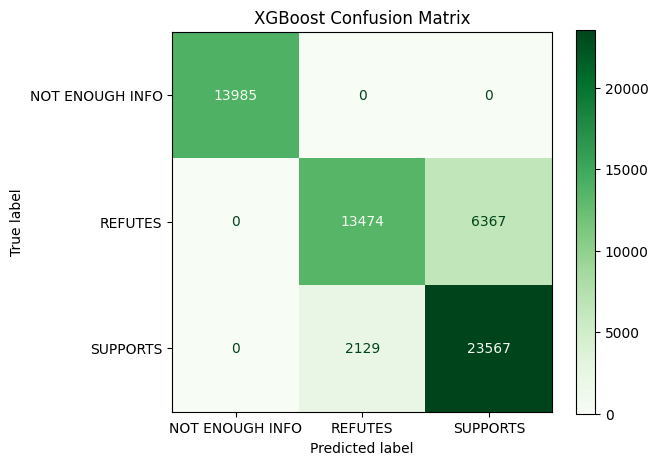


Overfitting Check:
Training Accuracy: 0.8669
Testing Accuracy:  0.8573
Model shows balanced generalization
XGBoost model saved as 'xgb_model.joblib'


In [5]:
os.environ["OMP_NUM_THREADS"] = "1"
is_apple_silicon = platform.machine() in ("arm64", "aarch64")

#-----------Data Split--------------------

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, stratify=y, random_state=42)

#------------Model Training--------------
xgb_params = {
    "n_estimators": 800,
    "learning_rate": 0.03,
    "reg_alpha": 0.1,     
    "reg_lambda": 1.0, 
    "max_depth": 4,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    "objective": "multi:softprob",
    "min_child_weight": 3,
    "num_class": len(label_enc.classes_),
    "eval_metric": "mlogloss",
    "random_state": 42,
    "verbosity": 1,
}
if is_apple_silicon:
    xgb_params.update({
        "tree_method": "approx",
        "device": "cpu",
        "n_jobs": max(1, os.cpu_count() // 2),
        #"n_jobs": 4,              
        "max_bin": 64,
    })
else:
    xgb_params.update({
        "tree_method": "hist",
        "n_jobs": -1,
    })

xgb_model = XGBClassifier(**xgb_params)


print("\nTraining XGBoost model")
xgb_model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True)

#---------------Predictions------------------------------

#y_pred = np.argmax(xgb_model.predict_proba(X_test), axis=1)
y_pred = xgb_model.predict(X_test)

#---------Evaluation Metrics---------------
print("\nXGBoost Results:\n")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(cmap="Greens", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

#------------------Overfitting Check-----------------------------
#train_pred = np.argmax(xgb_model.predict_proba(X_train), axis=1)
train_pred = xgb_model.predict(X_train)
train_acc = (train_pred == y_train).mean()
test_acc = (y_pred == y_test).mean()

print("\nOverfitting Check:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print("Possible overfitting detected")
elif test_acc - train_acc > 0.03:
    print("Model might be underfitting")
else:
    print("Model shows balanced generalization")

"""
#------------------Cross-Validation Check------------------------
cv_scores = cross_val_score(xgb_model, X_combined, y, cv=5, scoring="accuracy", n_jobs=1)
print("\nCross-validation scores:", np.round(cv_scores, 4))"""

#---------------Model Saving-------------------------------------
joblib.dump(xgb_model, "xgb_model.joblib")
print("XGBoost model saved as 'xgb_model.joblib'")


Using device: mps
Epoch 01/60|Train Acc: 0.8745|Val Acc: 0.8618
Epoch 02/60|Train Acc: 0.8995|Val Acc: 0.8792
Epoch 03/60|Train Acc: 0.9148|Val Acc: 0.8895
Epoch 04/60|Train Acc: 0.9277|Val Acc: 0.8991
Epoch 05/60|Train Acc: 0.9367|Val Acc: 0.9054
Epoch 06/60|Train Acc: 0.9434|Val Acc: 0.9083
Epoch 07/60|Train Acc: 0.9517|Val Acc: 0.9140
Epoch 08/60|Train Acc: 0.9556|Val Acc: 0.9153
Epoch 09/60|Train Acc: 0.9583|Val Acc: 0.9191
Epoch 10/60|Train Acc: 0.9616|Val Acc: 0.9205
Epoch 11/60|Train Acc: 0.9652|Val Acc: 0.9257
Epoch 12/60|Train Acc: 0.9687|Val Acc: 0.9265
Epoch 13/60|Train Acc: 0.9700|Val Acc: 0.9271
Epoch 14/60|Train Acc: 0.9726|Val Acc: 0.9293
Epoch 15/60|Train Acc: 0.9742|Val Acc: 0.9303
Epoch 16/60|Train Acc: 0.9748|Val Acc: 0.9331
Epoch 17/60|Train Acc: 0.9761|Val Acc: 0.9321
Epoch 18/60|Train Acc: 0.9771|Val Acc: 0.9307
Epoch 19/60|Train Acc: 0.9764|Val Acc: 0.9340
Epoch 20/60|Train Acc: 0.9777|Val Acc: 0.9311
Epoch 21/60|Train Acc: 0.9803|Val Acc: 0.9367
Epoch 22/60|Trai

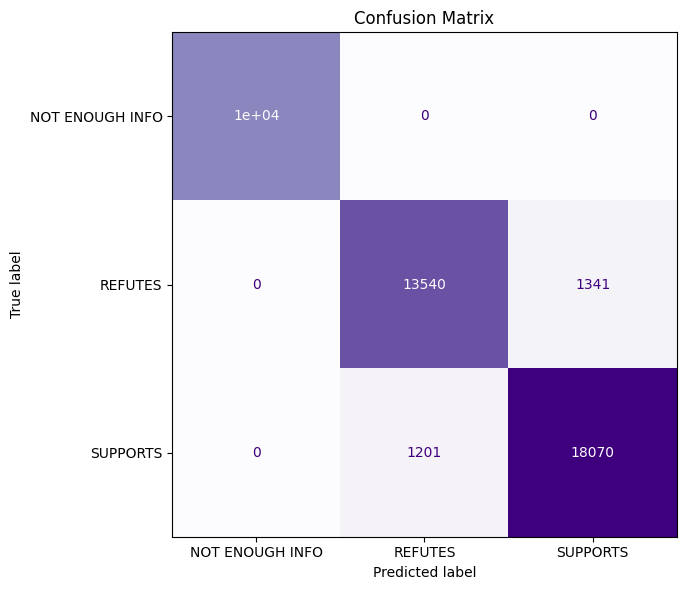


Final Accuracy:
Train Accuracy: 0.9877
Test  Accuracy: 0.9431
Model shows balanced generalization


In [5]:
#-------Reproducibility------------ 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("Using device:", device)


#--------------Stratified Splits------------------
X_arr = X_combined.toarray()    
y_arr = np.array(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_arr, y_arr, test_size=0.30, random_state=SEED, stratify=y_arr
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

#-----------Convert to tensors---------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

#-------------Dataloaders-------------
BATCH_SIZE = 128
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

#---------------Model Settings---------------
class mlp_model(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_t.shape[1]
output_dim = len(np.unique(y_arr))
model = mlp_model(input_dim, output_dim).to(device)


#-------Criterion,Optimizer,Scheduler------

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=5e-6
)
l1_lambda = 2e-5


#-----------Model Training----------------
num_epochs = 60
early_stop_patience = 8
patience_counter = 0
train_accs,val_accs = [], []

def compute_accuracy_model(model, dataloader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total if total > 0 else 0.0
    
best_val_acc = 0.0
for epoch in range(1, num_epochs + 1):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        l1 = sum(torch.sum(torch.abs(p)) for name, p in model.named_parameters() if "weight" in name)
        loss = loss + l1_lambda * l1
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

    train_acc = compute_accuracy_model(model, train_loader, device)
    val_acc = compute_accuracy_model(model, val_loader, device)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}/{num_epochs}|Train Acc: {train_acc:.4f}|Val Acc: {val_acc:.4f}")


    #--------Early stopping--------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "mlp_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered")
            break


#------------Model Saving-----------------
model.load_state_dict(torch.load("mlp_model.pth", map_location=device))
model.eval()

#---------------Predictions---------------
y_pred = []
y_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy())
        y_true.extend(yb.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)


#---------Evaluation Metrics---------------
print("\nMLP Results:\n")
print(classification_report(y_true, y_pred, target_names=label_enc.classes_, digits=4))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#------------------Overfitting Check-----------------------------
train_score = compute_accuracy_model(model, train_loader, device)
test_score = compute_accuracy_model(model, test_loader, device)

print("\nFinal Accuracy:")
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test  Accuracy: {test_score:.4f}")

if train_score - test_score > 0.05:
    print("Possible overfitting detected")
elif test_score - train_score > 0.03:
    print("Model might be underfitting")
else:
    print("Model shows balanced generalization")

5

Training LightGBM model

LightGBM Results:

                 precision    recall  f1-score   support

NOT ENOUGH INFO       1.00      1.00      1.00     13985
        REFUTES       0.91      0.79      0.85     19841
       SUPPORTS       0.85      0.94      0.89     25696

       accuracy                           0.90     59522
      macro avg       0.92      0.91      0.91     59522
   weighted avg       0.91      0.90      0.90     59522



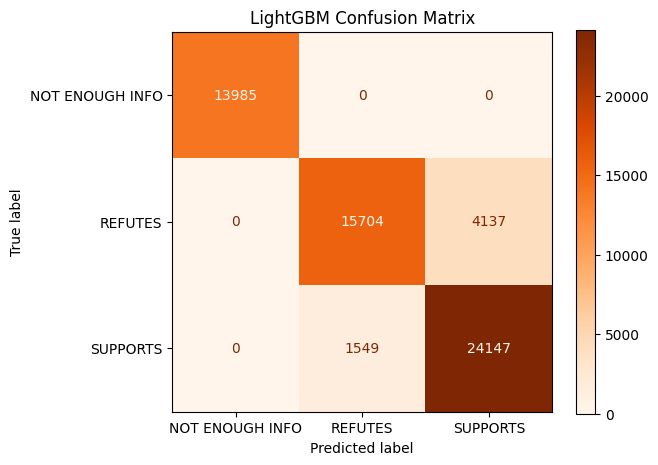


Overfitting Check:
Training Accuracy: 0.9297
Testing Accuracy:  0.9045
Model shows balanced generalization
LightGBM model saved as 'lgb_model.joblib'


In [12]:
#---------Imports---------------#
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import cross_val_score
import platform, os, joblib, numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)
#-----------Platform / thread handling-----------
is_apple_silicon = platform.machine() in ("arm64", "aarch64")
lgb_kwargs = {
    "n_estimators": 800,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "random_state": 42,
    "verbosity": -1, 
}
if is_apple_silicon:
    print(os.cpu_count() // 2)
    lgb_kwargs.update({"n_jobs": max(1, os.cpu_count() // 2)})
else:
    lgb_kwargs.update({"n_jobs": -1})

#------------Data Split------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, stratify=y, random_state=42
)

#------------Model Training--------------#
print("\nTraining LightGBM model")
lgb_model = LGBMClassifier(**lgb_kwargs,verbose =-1)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric="multi_logloss"
)

#---------------Predictions------------------------------
y_pred = lgb_model.predict(X_test)

#---------Evaluation Metrics---------------
print("\nLightGBM Results:\n")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(cmap="Oranges", values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.show()

#------------------Overfitting Check-----------------------------
train_pred = lgb_model.predict(X_train)
train_acc = (train_pred == y_train).mean()
test_acc = (y_pred == y_test).mean()

print("\nOverfitting Check:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print("Possible overfitting detected")
elif test_acc - train_acc > 0.03:
    print("Model might be underfitting")
else:
    print("Model shows balanced generalization")
"""
#------------------Cross-Validation Check------------------------
cv_scores = cross_val_score(lgb_model, X_combined, y, cv=5, scoring="accuracy", n_jobs=1)
print("\nCross-validation scores:", np.round(cv_scores, 4)) """

#---------------Model Saving-------------------------------------
joblib.dump(lgb_model, "lgb_model.joblib")
print("LightGBM model saved as 'lgb_model.joblib'")



Training CatBoost model
0:	learn: 1.0770677	test: 1.0771268	best: 1.0771268 (0)	total: 13.2s	remaining: 3h 17m 19s
1:	learn: 1.0556550	test: 1.0557851	best: 1.0557851 (1)	total: 26.1s	remaining: 3h 15m 39s
2:	learn: 1.0358615	test: 1.0361127	best: 1.0361127 (2)	total: 39.2s	remaining: 3h 15m 33s
3:	learn: 1.0168907	test: 1.0171827	best: 1.0171827 (3)	total: 52.4s	remaining: 3h 15m 42s
4:	learn: 0.9986159	test: 0.9990079	best: 0.9990079 (4)	total: 1m 5s	remaining: 3h 16m 27s
5:	learn: 0.9812703	test: 0.9816968	best: 0.9816968 (5)	total: 1m 19s	remaining: 3h 17m 17s
6:	learn: 0.9645895	test: 0.9651044	best: 0.9651044 (6)	total: 1m 33s	remaining: 3h 19m 14s
7:	learn: 0.9483606	test: 0.9488945	best: 0.9488945 (7)	total: 1m 48s	remaining: 3h 22m 1s
8:	learn: 0.9328525	test: 0.9334802	best: 0.9334802 (8)	total: 2m 4s	remaining: 3h 25m 28s
9:	learn: 0.9181094	test: 0.9187773	best: 0.9187773 (9)	total: 2m 20s	remaining: 3h 28m 33s
10:	learn: 0.9037928	test: 0.9045557	best: 0.9045557 (10)	tota

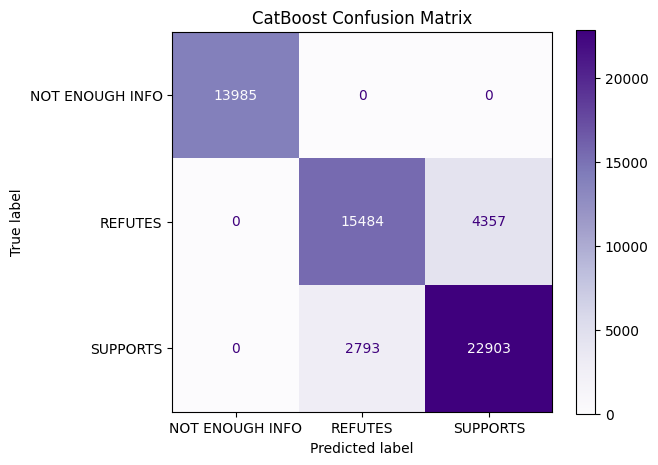


Overfitting Check:
Training Accuracy: 0.8992
Testing Accuracy:  0.8799
Model shows balanced generalization
CatBoost model saved as 'cat_model.joblib'


In [5]:
is_apple_silicon = platform.machine() in ("arm64", "aarch64")
#-------------------Model Params-----------
cat_kwargs = {
    "iterations": 900,
    "learning_rate": 0.02,
    "depth": 10,
    "loss_function": "MultiClass",
    "random_seed": 42,
    "auto_class_weights": "Balanced",
    "verbose": 1
}

if is_apple_silicon:
    cat_kwargs.update({"thread_count": max(1, os.cpu_count()//2)})
else:
    cat_kwargs.update({"thread_count": -1})

#------------Data Split------------------
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, stratify=y, random_state=42)

#----------Model Training------
print("\nTraining CatBoost model")
cat_model = CatBoostClassifier(**cat_kwargs)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

#---------------Predictions------------------------------
y_pred = cat_model.predict(X_test).astype(int).reshape(-1)

#---------Evaluation Metrics---------------
print("\nCatBoost Results:\n")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(cmap="Purples", values_format="d")
plt.title("CatBoost Confusion Matrix")
plt.tight_layout()
plt.show()

#------------------Overfitting Check-----------------------------
train_pred = cat_model.predict(X_train).astype(int).reshape(-1)
train_acc = (train_pred == y_train).mean()
test_acc = (y_pred == y_test).mean()

print("\nOverfitting Check:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print("Possible overfitting detected")
elif test_acc - train_acc > 0.03:
    print("Model might be underfitting")
else:
    print("Model shows balanced generalization")
"""
#------------------Cross-Validation Check------------------------
cv_scores = cross_val_score(cat_model, X_combined, y, cv=5, scoring="accuracy", n_jobs=1)
print("\nCross-validation scores:", np.round(cv_scores, 4))"""

#---------------Model Saving-------------------------------------
joblib.dump(cat_model, "cat_model.joblib")
print("CatBoost model saved as 'cat_model.joblib'")
